In [1]:

# TEMEL İMPORT'LAR VE AYARLAR

import os
import random
import numpy as np
import pandas as pd
from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import StratifiedKFold, train_test_split, ParameterSampler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    auc,
    cohen_kappa_score,
    top_k_accuracy_score,
    average_precision_score,
    precision_score,
    recall_score
)


Bu hücrede projenin temel kurulumunu yaptım. Gerekli kütüphaneleri import ettim.

In [2]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["font.size"] = 12

def set_seed(seed=42):
    """Reproducibility için seed ayarı"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Kullanılan cihaz: {device}")
print(f"✅ PyTorch versiyon: {torch.__version__}")

# Konfigürasyon
class Config:
    IMG_SIZE = 224
    BATCH_SIZE = 32
    NUM_WORKERS = 0
    N_SPLITS = 5
    RANDOM_STATE = 42
    RANDOM_SEARCH_ITER = 5
    RANDOM_SEARCH_PARAMS = {
        'lr': [1e-4, 5e-4, 1e-3, 1e-5],
        'weight_decay': [1e-4, 1e-5, 1e-3],
        'dropout': [0.3, 0.5, 0.7]
    }
    
    # EĞİTİM PARAMETRELERİ
    PHASE1_EPOCHS = 5      # Head training
    PHASE2_EPOCHS = 20     # Fine-tuning
    EARLY_STOP_PATIENCE = 5

config = Config()

✅ Kullanılan cihaz: cuda
✅ PyTorch versiyon: 2.5.1+cu121


Tekrarlanabilirlik için seed ayarladım, GPU kullanımını kontrol ettim ve tüm proje ayarlarını bir Config sınıfında topladım.

In [3]:
# VERİ YÜKLEME VE HAZIRLIK

DATASET_DIR = r"C:\Users\Kardelen\Desktop\dlp\garbage-dataset"

class_names = sorted([
    d for d in os.listdir(DATASET_DIR)
    if os.path.isdir(os.path.join(DATASET_DIR, d))
])

num_classes = len(class_names)
class_to_idx = {cls: idx for idx, cls in enumerate(class_names)}
idx_to_class = {idx: cls for cls, idx in class_to_idx.items()}

print(f"✅ Toplam {num_classes} sınıf bulundu:")
for i, cls in enumerate(class_names):
    print(f"  {i:2d}: {cls}")

data = []
for cls in class_names:
    cls_path = os.path.join(DATASET_DIR, cls)
    images = [
        f for f in os.listdir(cls_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
    ]
    
    for img in images:
        data.append({
            "image_path": os.path.join(cls_path, img),
            "label": class_to_idx[cls],
            "class_name": cls
        })

df = pd.DataFrame(data)
print(f"\n✅ Toplam {len(df)} görüntü yüklendi")

class_distribution = df["class_name"].value_counts().reset_index()
class_distribution.columns = ["Class", "Image_Count"]

print("\n📊 Sınıf Bazlı Dağılım:")
print(class_distribution.to_string(index=False))


✅ Toplam 10 sınıf bulundu:
   0: battery
   1: biological
   2: cardboard
   3: clothes
   4: glass
   5: metal
   6: paper
   7: plastic
   8: shoes
   9: trash

✅ Toplam 19762 görüntü yüklendi

📊 Sınıf Bazlı Dağılım:
     Class  Image_Count
   clothes         5327
     glass         3061
   plastic         1984
     shoes         1977
 cardboard         1825
     paper         1680
     metal         1020
biological          997
     trash          947
   battery          944


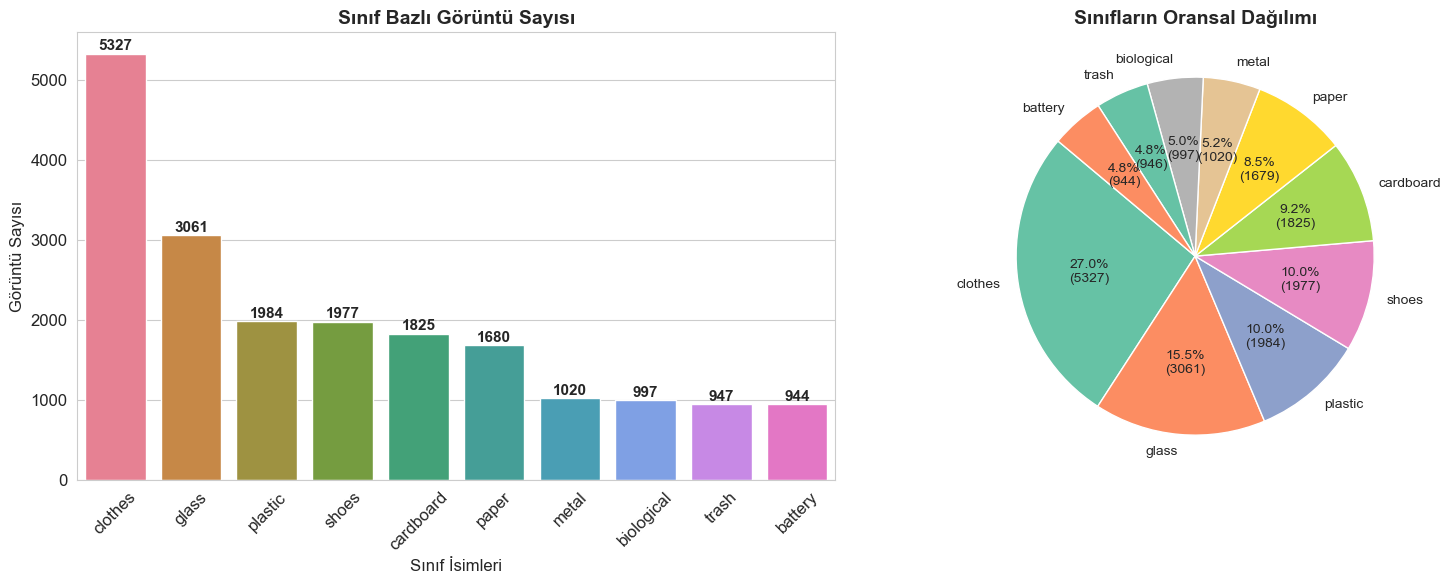

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#Bar chart 
sns.barplot(x="Class", y="Image_Count", data=class_distribution, 
            hue="Class", palette="husl", legend=False, ax=axes[0])
axes[0].set_title("Sınıf Bazlı Görüntü Sayısı", fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_xlabel("Sınıf İsimleri", fontsize=12)
axes[0].set_ylabel("Görüntü Sayısı", fontsize=12)


for i, count in enumerate(class_distribution["Image_Count"]):
    axes[0].text(i, count + 5, str(count), ha='center', va='bottom', fontsize=11, fontweight='bold')
#Pie chart
axes[1].pie(class_distribution["Image_Count"], 
           labels=class_distribution["Class"], 
           autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100*sum(class_distribution["Image_Count"]))})',
           startangle=140,
           colors=sns.color_palette("Set2"),
           textprops={'fontsize': 10})
axes[1].set_title("Sınıfların Oransal Dağılımı", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()



In [5]:
print(f"\n📈 Temel İstatistikler:")
print(f"• En az görüntü: {class_distribution['Image_Count'].min()} ({class_distribution.loc[class_distribution['Image_Count'].idxmin(), 'Class']})")
print(f"• En çok görüntü: {class_distribution['Image_Count'].max()} ({class_distribution.loc[class_distribution['Image_Count'].idxmax(), 'Class']})")
print(f"• Toplam görüntü: {class_distribution['Image_Count'].sum()}")



📈 Temel İstatistikler:
• En az görüntü: 944 (battery)
• En çok görüntü: 5327 (clothes)
• Toplam görüntü: 19762


Veri setimi yükledim ve analiz ettim. Bar chart ve pie chart kullanarak sınıf dağılımını görselleştirdim. Bar chart'ta her sınıfın tam görüntü sayısını çubukların üzerine yazdım, pie chart'ta ise hem yüzdelik hem de gerçek sayıyı gösterdim. Temel istatistikleri de alt kısımda yazdırdım.

In [6]:

# STRATIFIED SPLIT VE DATA TRANSFORMS

# Stratified Split
X = df["image_path"].values
y = df["label"].values

skf = StratifiedKFold(n_splits=config.N_SPLITS, shuffle=True, 
                      random_state=config.RANDOM_STATE)

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    print(f"✅ Fold {fold + 1} seçildi")
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    break

train_df = df.iloc[train_idx].reset_index(drop=True)
test_df = df.iloc[test_idx].reset_index(drop=True)

print(f"\n📊 Split sonuçları:")
print(f"  Train örnek sayısı: {len(train_df)} ({len(train_df)/len(df)*100:.1f}%)")
print(f"  Test örnek sayısı : {len(test_df)} ({len(test_df)/len(df)*100:.1f}%)")

# Train-Validation split (stratified)
train_df_split, val_df = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df["label"],
    random_state=config.RANDOM_STATE
)

print(f"  Final Train : {len(train_df_split)}")
print(f"  Validation  : {len(val_df)}")


✅ Fold 1 seçildi

📊 Split sonuçları:
  Train örnek sayısı: 15809 (80.0%)
  Test örnek sayısı : 3953 (20.0%)
  Final Train : 12647
  Validation  : 3162


Veri setimi sınıf dağılımını koruyarak böldüm. Önce 5-fold cross validation'dan ilk fold'u seçtim, sonra train setinden validation için %20 ayırdım.

In [7]:
# Transforms
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((config.IMG_SIZE, config.IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, 
                          saturation=0.2, hue=0.1),
    transforms.RandomResizedCrop(config.IMG_SIZE, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

val_test_transforms = transforms.Compose([
    transforms.Resize((config.IMG_SIZE, config.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])


Train için data augmentation (çevirme, döndürme, renk ayarı) ekledim ki model daha iyi generalize etsin. Val ve test için ise sadece normalizasyon yaptım. 

In [8]:
# Dataset sınıfı
class TrashDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform
    
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        
        if self.transform:
            image = self.transform(image)
        
        return {
            "image": image,
            "label": row["label"],
            "class_name": row["class_name"],
            "image_path": row["image_path"]
        }

# Datasets
train_dataset = TrashDataset(train_df_split, transform=train_transforms)
val_dataset = TrashDataset(val_df, transform=val_test_transforms)
test_dataset = TrashDataset(test_df, transform=val_test_transforms)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, 
                         shuffle=True, num_workers=config.NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, 
                       shuffle=False, num_workers=config.NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE, 
                        shuffle=False, num_workers=config.NUM_WORKERS)

print(f"\n✅ DataLoaders oluşturuldu:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches  : {len(val_loader)}")
print(f"  Test batches : {len(test_loader)}")


✅ DataLoaders oluşturuldu:
  Train batches: 396
  Val batches  : 99
  Test batches : 124


Özel bir Dataset sınıfı yazarak görüntüleri yükleme ve dönüştürme işlemlerini otomatikleştirdim. Son olarak DataLoader'ları oluşturdum ve her set için batch sayılarını kontrol ettim.

In [9]:
# CONVNEXT-TINY MODEL FONKSİYONLARI

def get_convnext_tiny(num_classes, dropout_rate=0.5):
    
    model = models.convnext_tiny(weights="DEFAULT")
    
    print(f"✅ ConvNeXt-Tiny yüklendi")
    print(f"   Özellik çıkarma katmanı: {model.features[-1][-1]}")
    
    in_features = model.classifier[-1].in_features
    
    model.classifier = nn.Sequential(
        nn.AdaptiveAvgPool2d((1, 1)),  
        nn.Flatten(start_dim=1),
        nn.LayerNorm(in_features),    
        nn.Linear(in_features, 512),
        nn.GELU(),    
        nn.Dropout(dropout_rate),
        nn.Linear(512, num_classes)
    )
    
    return model

def freeze_backbone(model):
    
    # Features kısmını dondur
    for param in model.features.parameters():
        param.requires_grad = False
    print("✅ Backbone donduruldu")

def unfreeze_last_stages(model, num_stages=1):
    
    stages = list(model.features.children())
    
    # Son stage'leri aç
    for stage in stages[-num_stages:]:
        for param in stage.parameters():
            param.requires_grad = True
    
    print(f"✅ Son {num_stages} stage açıldı")

def print_trainable_params(model):
    
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    
    print(f"📊 Model parametreleri:")
    print(f"   Eğitilebilir: {trainable:,} ({trainable/total*100:.1f}%)")
    print(f"   Toplam      : {total:,}")
    
    return trainable, total

ConvNeXt-Tiny modelimi özelleştirmek için fonksiyonlar yazdım. get_convnext_tiny() ile ImageNet'te ön eğitilmiş modeli yükleyip, son classifier katmanını kendi sınıf sayıma göre değiştirdim. Transfer learning için freeze_backbone() ile modelin özellik çıkarma kısmını dondurdum, böylece sadece yeni eklediğim katmanlar eğitilecek. İstersem unfreeze_last_stages() ile son katmanları da açabilirim. print_trainable_params() ile de modelin ne kadarının eğitileceğini kontrol ediyorum. Bu stratejiyle hem önceden öğrenilmiş bilgileri koruyorum hem de modeli kendi verime adapte ediyorum.

In [10]:
# YARDIMCI FONKSİYONLAR

def calculate_accuracy(outputs, labels):
    _, preds = torch.max(outputs, 1)
    return (preds == labels).sum().item() / labels.size(0)

class EarlyStopping:
    def __init__(self, patience=5, delta=0.0):
        self.patience = patience
        self.delta = delta
        self.best_loss = np.inf
        self.counter = 0
        self.early_stop = False
    
    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        return self.early_stop

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss, running_acc = 0.0, 0.0
    
    for batch in tqdm(loader, desc="Training", leave=False):
        images = batch["image"].to(device)
        labels = batch["label"].to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        running_acc += calculate_accuracy(outputs, labels)
    
    return running_loss / len(loader), running_acc / len(loader)

def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss, running_acc = 0.0, 0.0
    
    with torch.no_grad():
        for batch in tqdm(loader, desc="Validation", leave=False):
            images = batch["image"].to(device)
            labels = batch["label"].to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            running_acc += calculate_accuracy(outputs, labels)
    
    return running_loss / len(loader), running_acc / len(loader)

Model eğitimi için yardımcı fonksiyonlar yazdım. calculate_accuracy ile modelin doğruluk oranını hesaplıyorum. EarlyStopping sınıfıyla model overfit olmadan eğitimi durdurabiliyorum - validation loss 5 epoch boyunca iyileşmezse duruyor. train_one_epoch fonksiyonunda tüm batch'leri eğitiyorum, forward-backward pass yapıp optimizer ile parametreleri güncelliyorum. validate_one_epoch ile de modelin validation setindeki performansını ölçüyorum, burada gradien hesaplama yok çünkü sadece değerlendirme yapıyorum. Bu fonksiyonlar sayesinde eğitim kodum daha temiz ve yönetilebilir oluyor.

In [11]:
# RANDOM SEARCH FONKSİYONU

def random_search_training(param_grid, n_iter=5):
    
    print(f"\n{'='*60}")
    print("🎯 RANDOM SEARCH BAŞLIYOR")
    print(f"{'='*60}")
    
    class_weights = compute_class_weight(
        class_weight="balanced",
        classes=np.unique(train_df_split["label"]),
        y=train_df_split["label"]
    )
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    
    param_list = list(ParameterSampler(
        param_grid, n_iter=n_iter, random_state=config.RANDOM_STATE
    ))
    
    results = []
    
    for i, params in enumerate(param_list):
        print(f"\n🔍 DENEME {i+1}/{n_iter}")
        print(f"   LR: {params['lr']:.0e}, WD: {params['weight_decay']:.0e}, Dropout: {params['dropout']}")
        
        # Model oluştur
        model_rs = get_convnext_tiny(
            num_classes=num_classes,
            dropout_rate=params['dropout']
        ).to(device)
        
        # Backbone'u dondur
        freeze_backbone(model_rs)
        
        # Optimizer
        optimizer = optim.AdamW(
            filter(lambda p: p.requires_grad, model_rs.parameters()),
            lr=params['lr'],
            weight_decay=params['weight_decay']
        )
        
        best_val_loss = np.inf
        best_val_acc = 0
        
        for epoch in range(5):
            train_loss, _ = train_one_epoch(
                model_rs, train_loader, optimizer, criterion, device
            )
            val_loss, val_acc = validate_one_epoch(
                model_rs, val_loader, criterion, device
            )
            
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_val_acc = val_acc
                best_state = model_rs.state_dict()

        results.append({
            'params': params,
            'best_val_loss': best_val_loss,
            'best_val_acc': best_val_acc,
            'model_state': best_state
        })
        
        print(f"   ➤ Val Loss: {best_val_loss:.4f}, Val Acc: {best_val_acc:.4f}")
    
    best_result = min(results, key=lambda x: x['best_val_loss'])
    
    print(f"\n{'='*60}")
    print("🏆 RANDOM SEARCH SONUÇLARI")
    print(f"{'='*60}")
    
    for i, res in enumerate(results):
        print(f"Trial {i+1}: "
              f"LR={res['params']['lr']:.1e}, "
              f"WD={res['params']['weight_decay']:.1e}, "
              f"Dropout={res['params']['dropout']} → "
              f"Loss: {res['best_val_loss']:.4f}")
    
    print(f"\n✅ EN İYİ PARAMETRELER:")
    print(f"   Learning Rate: {best_result['params']['lr']}")
    print(f"   Weight Decay : {best_result['params']['weight_decay']}")
    print(f"   Dropout      : {best_result['params']['dropout']}")
    print(f"   Val Loss     : {best_result['best_val_loss']:.4f}")
    print(f"   Val Acc      : {best_result['best_val_acc']:.4f}")
    
    return best_result, results

Random search fonksiyonumu yazdım. 5 farklı parametre kombinasyonunu eğiterek en iyi learning rate, weight decay ve dropout değerlerini buluyorum. Imbalanced veri için class weights hesaplıyorum, her denemede yeni model oluşturup backbone'u donduruyorum. En düşük validation loss'a sahip parametreleri seçip sonuçları raporluyorum.

In [12]:
# RANDOM SEARCH ÇALIŞTIR VE MODEL OLUŞTUR

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df_split["label"]),
    y=train_df_split["label"]
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

# Loss fonksiyonu (Weighted CrossEntropyLoss)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

print("📊 Class weights:")
for idx, weight in enumerate(class_weights):
    print(f"  {idx_to_class[idx]:<10} → {weight:.4f}")

# Random Search çalıştır
best_result, all_results = random_search_training(
    param_grid=config.RANDOM_SEARCH_PARAMS,
    n_iter=config.RANDOM_SEARCH_ITER
)

best_params = best_result['params']

print(f"\n{'='*60}")
print("🤖 EN İYİ PARAMETRELERLE MODEL OLUŞTURULUYOR")
print(f"{'='*60}")

model = get_convnext_tiny(
    num_classes=num_classes,
    dropout_rate=best_params['dropout']
).to(device)

model.load_state_dict(best_result['model_state'])
print(f"✅ Model oluşturuldu ve yüklendi")

trainable, total = print_trainable_params(model)

random_search_df = pd.DataFrame([
    {
        'Trial': i+1,
        'Learning_Rate': f"{r['params']['lr']:.1e}",
        'Weight_Decay': f"{r['params']['weight_decay']:.1e}",
        'Dropout': r['params']['dropout'],
        'Val_Loss': f"{r['best_val_loss']:.4f}",
        'Val_Acc': f"{r['best_val_acc']:.4f}"
    }
    for i, r in enumerate(all_results)
])

print(f"\n📋 Random Search Sonuçları:")
print(random_search_df.to_string(index=False))

📊 Class weights:
  battery    → 2.0939
  biological → 1.9823
  cardboard  → 1.0828
  clothes    → 0.3710
  glass      → 0.6456
  metal      → 1.9368
  paper      → 1.1765
  plastic    → 0.9966
  shoes      → 0.9990
  trash      → 2.0870

🎯 RANDOM SEARCH BAŞLIYOR

🔍 DENEME 1/5
   LR: 1e-05, WD: 1e-03, Dropout: 0.7
✅ ConvNeXt-Tiny yüklendi
   Özellik çıkarma katmanı: CNBlock(
  (block): Sequential(
    (0): Conv2d(768, 768, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=768)
    (1): Permute()
    (2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
    (3): Linear(in_features=768, out_features=3072, bias=True)
    (4): GELU(approximate='none')
    (5): Linear(in_features=3072, out_features=768, bias=True)
    (6): Permute()
  )
  (stochastic_depth): StochasticDepth(p=0.1, mode=row)
)
✅ Backbone donduruldu


   ➤ Val Loss: 0.6596, Val Acc: 0.9068

🔍 DENEME 2/5
   LR: 1e-04, WD: 1e-05, Dropout: 0.5
✅ ConvNeXt-Tiny yüklendi
   Özellik çıkarma katmanı: CNBlock(
  (block): Sequential(
    (0): Conv2d(768, 768, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=768)
    (1): Permute()
    (2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
    (3): Linear(in_features=768, out_features=3072, bias=True)
    (4): GELU(approximate='none')
    (5): Linear(in_features=3072, out_features=768, bias=True)
    (6): Permute()
  )
  (stochastic_depth): StochasticDepth(p=0.1, mode=row)
)
✅ Backbone donduruldu


   ➤ Val Loss: 0.1879, Val Acc: 0.9485

🔍 DENEME 3/5
   LR: 1e-04, WD: 1e-03, Dropout: 0.7
✅ ConvNeXt-Tiny yüklendi
   Özellik çıkarma katmanı: CNBlock(
  (block): Sequential(
    (0): Conv2d(768, 768, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=768)
    (1): Permute()
    (2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
    (3): Linear(in_features=768, out_features=3072, bias=True)
    (4): GELU(approximate='none')
    (5): Linear(in_features=3072, out_features=768, bias=True)
    (6): Permute()
  )
  (stochastic_depth): StochasticDepth(p=0.1, mode=row)
)
✅ Backbone donduruldu


   ➤ Val Loss: 0.2037, Val Acc: 0.9470

🔍 DENEME 4/5
   LR: 1e-03, WD: 1e-04, Dropout: 0.7
✅ ConvNeXt-Tiny yüklendi
   Özellik çıkarma katmanı: CNBlock(
  (block): Sequential(
    (0): Conv2d(768, 768, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=768)
    (1): Permute()
    (2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
    (3): Linear(in_features=768, out_features=3072, bias=True)
    (4): GELU(approximate='none')
    (5): Linear(in_features=3072, out_features=768, bias=True)
    (6): Permute()
  )
  (stochastic_depth): StochasticDepth(p=0.1, mode=row)
)
✅ Backbone donduruldu


   ➤ Val Loss: 0.1428, Val Acc: 0.9615

🔍 DENEME 5/5
   LR: 5e-04, WD: 1e-05, Dropout: 0.5
✅ ConvNeXt-Tiny yüklendi
   Özellik çıkarma katmanı: CNBlock(
  (block): Sequential(
    (0): Conv2d(768, 768, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=768)
    (1): Permute()
    (2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
    (3): Linear(in_features=768, out_features=3072, bias=True)
    (4): GELU(approximate='none')
    (5): Linear(in_features=3072, out_features=768, bias=True)
    (6): Permute()
  )
  (stochastic_depth): StochasticDepth(p=0.1, mode=row)
)
✅ Backbone donduruldu


   ➤ Val Loss: 0.1508, Val Acc: 0.9596

🏆 RANDOM SEARCH SONUÇLARI
Trial 1: LR=1.0e-05, WD=1.0e-03, Dropout=0.7 → Loss: 0.6596
Trial 2: LR=1.0e-04, WD=1.0e-05, Dropout=0.5 → Loss: 0.1879
Trial 3: LR=1.0e-04, WD=1.0e-03, Dropout=0.7 → Loss: 0.2037
Trial 4: LR=1.0e-03, WD=1.0e-04, Dropout=0.7 → Loss: 0.1428
Trial 5: LR=5.0e-04, WD=1.0e-05, Dropout=0.5 → Loss: 0.1508

✅ EN İYİ PARAMETRELER:
   Learning Rate: 0.001
   Weight Decay : 0.0001
   Dropout      : 0.7
   Val Loss     : 0.1428
   Val Acc      : 0.9615

🤖 EN İYİ PARAMETRELERLE MODEL OLUŞTURULUYOR
✅ ConvNeXt-Tiny yüklendi
   Özellik çıkarma katmanı: CNBlock(
  (block): Sequential(
    (0): Conv2d(768, 768, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=768)
    (1): Permute()
    (2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
    (3): Linear(in_features=768, out_features=3072, bias=True)
    (4): GELU(approximate='none')
    (5): Linear(in_features=3072, out_features=768, bias=True)
    (6): Permute()
  )
  (st

Random search ile bulduğum en iyi hiperparametrelerle modelimi oluşturuyorum. İmbalanced veri için class weights hesaplayıp yazdırıyorum. Random search'te eğitilmiş modelin ağırlıklarını yeni modele yüklüyorum. Model parametrelerini kontrol edip tüm deneme sonuçlarını DataFrame'de gösteriyorum. Model detaylı eğitime hazır.

In [13]:
# PHASE 1 - HEAD TRAINING

print(f"\n{'='*60}")
print("🟢 PHASE 1 - HEAD TRAINING (5 Epoch)")
print(f"{'='*60}")

# Backbone'u dondur (sadece classifier eğitilecek)
freeze_backbone(model)

# Optimizer (Random Search'ten gelen LR)
optimizer_phase1 = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=best_params['lr'],
    weight_decay=best_params['weight_decay']
)

scheduler_phase1 = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_phase1,
    T_max=config.PHASE1_EPOCHS,
    eta_min=1e-5
)

# Early Stopping
early_stopping = EarlyStopping(patience=3)

phase1_train_losses, phase1_val_losses = [], []
phase1_train_accs, phase1_val_accs = [], []
best_val_loss = np.inf

print(f"\n📈 Phase 1 başlıyor...")
print(f"   Epochs: {config.PHASE1_EPOCHS}")
print(f"   Learning Rate: {best_params['lr']}")
print(f"   Weight Decay: {best_params['weight_decay']}")

for epoch in range(config.PHASE1_EPOCHS):
    print(f"\n📚 Epoch {epoch+1}/{config.PHASE1_EPOCHS}")
    
    # Training
    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer_phase1, criterion, device
    )
    
    # Validation
    val_loss, val_acc = validate_one_epoch(
        model, val_loader, criterion, device
    )
    
    scheduler_phase1.step()
    
    phase1_train_losses.append(train_loss)
    phase1_val_losses.append(val_loss)
    phase1_train_accs.append(train_acc)
    phase1_val_accs.append(val_acc)
    
    print(f"   Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f}")
    print(f"   Val Loss  : {val_loss:.4f} | Acc: {val_acc:.4f}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "convnext_best_phase1.pt")
        print(f"   💾 Best model kaydedildi (Loss: {val_loss:.4f})")
    
    if early_stopping(val_loss):
        print(f"   ⏹️ Early stopping triggered!")
        break

print(f"\n✅ Phase 1 tamamlandı!")
print(f"   En iyi Val Loss: {best_val_loss:.4f}")
print(f"   Son Val Acc: {phase1_val_accs[-1]:.4f}")



🟢 PHASE 1 - HEAD TRAINING (5 Epoch)
✅ Backbone donduruldu

📈 Phase 1 başlıyor...
   Epochs: 5
   Learning Rate: 0.001
   Weight Decay: 0.0001

📚 Epoch 1/5


   Train Loss: 0.2134 | Acc: 0.9365
   Val Loss  : 0.1786 | Acc: 0.9555
   💾 Best model kaydedildi (Loss: 0.1786)

📚 Epoch 2/5


   Train Loss: 0.1844 | Acc: 0.9468
   Val Loss  : 0.1528 | Acc: 0.9599
   💾 Best model kaydedildi (Loss: 0.1528)

📚 Epoch 3/5


   Train Loss: 0.1670 | Acc: 0.9458
   Val Loss  : 0.1384 | Acc: 0.9669
   💾 Best model kaydedildi (Loss: 0.1384)

📚 Epoch 4/5


   Train Loss: 0.1415 | Acc: 0.9571
   Val Loss  : 0.1333 | Acc: 0.9669
   💾 Best model kaydedildi (Loss: 0.1333)

📚 Epoch 5/5


   Train Loss: 0.1235 | Acc: 0.9594
   Val Loss  : 0.1319 | Acc: 0.9662
   💾 Best model kaydedildi (Loss: 0.1319)

✅ Phase 1 tamamlandı!
   En iyi Val Loss: 0.1319
   Son Val Acc: 0.9662


Phase 1 (head training) eğitimimi başlatıyorum. Modelin backbone katmanlarını dondurarak sadece classifier kısmını eğiteceğim. Random search'ten gelen en iyi learning rate ve weight decay değerlerini kullanıyorum. CosineAnnealingLR scheduler ile learning rate'i epoch ilerledikçe azaltacağım, early stopping ile de overfitting'i önleyeceğim.

Her epoch'ta train ve validation loss/accuracy değerlerini takip ediyorum, en iyi modeli kaydediyorum. 

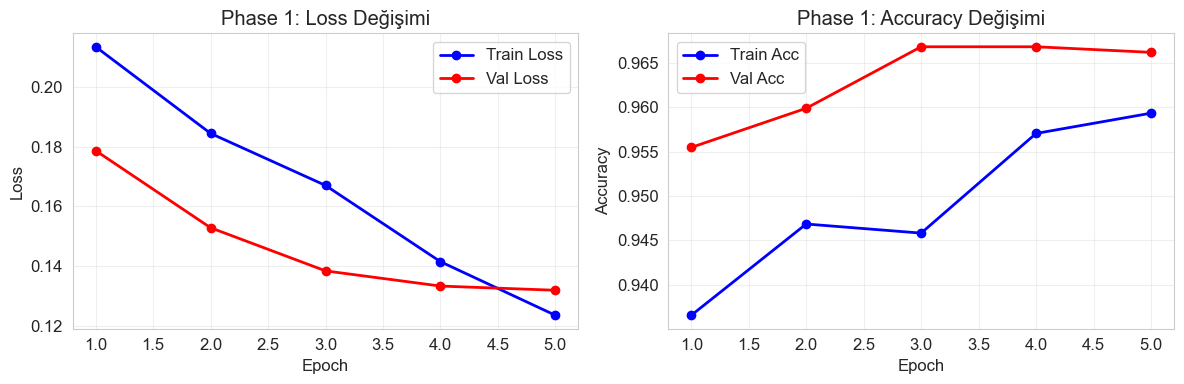

In [14]:
# Phase 1 grafikleri
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss grafiği
axes[0].plot(range(1, len(phase1_train_losses)+1), phase1_train_losses, 
            'b-o', label='Train Loss', linewidth=2)
axes[0].plot(range(1, len(phase1_val_losses)+1), phase1_val_losses, 
            'r-o', label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Phase 1: Loss Değişimi')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy grafiği
axes[1].plot(range(1, len(phase1_train_accs)+1), phase1_train_accs, 
            'b-o', label='Train Acc', linewidth=2)
axes[1].plot(range(1, len(phase1_val_accs)+1), phase1_val_accs, 
            'r-o', label='Val Acc', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Phase 1: Accuracy Değişimi')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Eğitim sonunda loss ve accuracy grafiklerini çizdirerek modelimin öğrenme sürecini görselleştiriyorum. Phase 1'de amaç, modelin yeni veriye uyum sağlayacak temel özellikleri öğrenmesi.

In [15]:
# PHASE 2 - FINE TUNING

print(f"\n{'='*60}")
print("🔵 PHASE 2 - FINE TUNING")
print(f"{'='*60}")

# Son stage'leri aç (unfreeze)
print("\n🔓 Son stage'ler açılıyor...")
unfreeze_last_stages(model, num_stages=1)

fine_tune_lr = max(best_params['lr'] * 0.1, 1e-5)  # Daha düşük LR

# Optimizer
optimizer_phase2 = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=fine_tune_lr,
    weight_decay=best_params['weight_decay']
)

# Scheduler
scheduler_phase2 = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_phase2,
    T_max=config.PHASE2_EPOCHS,
    eta_min=1e-6
)

# Early Stopping
early_stopping = EarlyStopping(patience=config.EARLY_STOP_PATIENCE)

phase2_train_losses, phase2_val_losses = [], []
phase2_train_accs, phase2_val_accs = [], []
best_val_loss = min(phase1_val_losses)

print(f"\n📈 Phase 2 başlıyor...")
print(f"   Max Epochs: {config.PHASE2_EPOCHS}")
print(f"   Learning Rate: {fine_tune_lr:.1e} (Fine-tuning için düşük)")
print(f"   Early Stopping Patience: {config.EARLY_STOP_PATIENCE}")

for epoch in range(config.PHASE2_EPOCHS):
    print(f"\n📚 Epoch {epoch+1}/{config.PHASE2_EPOCHS}")
    
    # Training
    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer_phase2, criterion, device
    )
    
    # Validation
    val_loss, val_acc = validate_one_epoch(
        model, val_loader, criterion, device
    )
    
    # Scheduler update
    scheduler_phase2.step()
    
    phase2_train_losses.append(train_loss)
    phase2_val_losses.append(val_loss)
    phase2_train_accs.append(train_acc)
    phase2_val_accs.append(val_acc)
    
    print(f"   Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f}")
    print(f"   Val Loss  : {val_loss:.4f} | Acc: {val_acc:.4f}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "convnext_best_final.pt")
        print(f"   💾 Best model güncellendi (Loss: {val_loss:.4f})")
    
    if early_stopping(val_loss):
        print(f"   ⏹️ Early stopping triggered!")
        break

print(f"\n✅ Phase 2 tamamlandı!")
print(f"   Toplam epoch: {len(phase2_train_losses)}")
print(f"   En iyi Val Loss: {best_val_loss:.4f}")
print(f"   Son Val Acc: {phase2_val_accs[-1]:.4f}")




🔵 PHASE 2 - FINE TUNING

🔓 Son stage'ler açılıyor...
✅ Son 1 stage açıldı

📈 Phase 2 başlıyor...
   Max Epochs: 20
   Learning Rate: 1.0e-04 (Fine-tuning için düşük)
   Early Stopping Patience: 5

📚 Epoch 1/20


   Train Loss: 0.1207 | Acc: 0.9605
   Val Loss  : 0.1377 | Acc: 0.9700

📚 Epoch 2/20


   Train Loss: 0.1043 | Acc: 0.9682
   Val Loss  : 0.1292 | Acc: 0.9688
   💾 Best model güncellendi (Loss: 0.1292)

📚 Epoch 3/20


   Train Loss: 0.0773 | Acc: 0.9746
   Val Loss  : 0.1175 | Acc: 0.9747
   💾 Best model güncellendi (Loss: 0.1175)

📚 Epoch 4/20


   Train Loss: 0.0618 | Acc: 0.9803
   Val Loss  : 0.1225 | Acc: 0.9741

📚 Epoch 5/20


   Train Loss: 0.0559 | Acc: 0.9816
   Val Loss  : 0.1342 | Acc: 0.9716

📚 Epoch 6/20


   Train Loss: 0.0416 | Acc: 0.9862
   Val Loss  : 0.1343 | Acc: 0.9744

📚 Epoch 7/20


   Train Loss: 0.0443 | Acc: 0.9863
   Val Loss  : 0.1314 | Acc: 0.9738

📚 Epoch 8/20


   Train Loss: 0.0334 | Acc: 0.9880
   Val Loss  : 0.1417 | Acc: 0.9738
   ⏹️ Early stopping triggered!

✅ Phase 2 tamamlandı!
   Toplam epoch: 8
   En iyi Val Loss: 0.1175
   Son Val Acc: 0.9738


Phase 2 (fine-tuning) başlatıyorum. Modelin son katmanlarını açıp tüm modeli eğitiyorum. Learning rate'i Phase 1'den 10 kat düşük ayarlıyorum. Cosine annealing scheduler ve early stopping kullanarak 20 epoch boyunca eğitiyorum. En iyi modeli kaydediyorum.

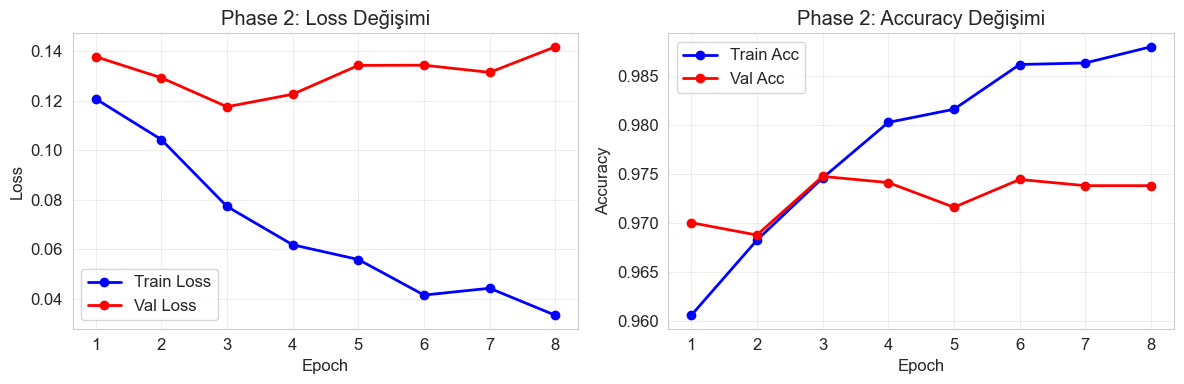

✅ En iyi final model yüklendi


In [16]:
# Phase 2 grafikleri
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss grafiği
axes[0].plot(range(1, len(phase2_train_losses)+1), phase2_train_losses, 
            'b-o', label='Train Loss', linewidth=2)
axes[0].plot(range(1, len(phase2_val_losses)+1), phase2_val_losses, 
            'r-o', label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Phase 2: Loss Değişimi')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy grafiği
axes[1].plot(range(1, len(phase2_train_accs)+1), phase2_train_accs, 
            'b-o', label='Train Acc', linewidth=2)
axes[1].plot(range(1, len(phase2_val_accs)+1), phase2_val_accs, 
            'r-o', label='Val Acc', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Phase 2: Accuracy Değişimi')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
model.load_state_dict(torch.load("convnext_best_final.pt", 
                                 map_location=device, 
                                 weights_only=True))


print("✅ En iyi final model yüklendi")

Grafiklerle performansı görüntülüyorum ve kaydettiğim en iyi modeli yüklüyorum.

In [17]:

# TEST DEĞERLENDİRME VE METRİKLER

print(f"\n{'='*60}")
print("🧪 TEST SETİ DEĞERLENDİRMESİ")
print(f"{'='*60}")

model.eval()

all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Test Evaluation"):
        images = batch["image"].to(device)
        labels = batch["label"].to(device)
        
        outputs = model(images)
        probs = F.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)
        
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)

print(f"✅ Test değerlendirmesi tamamlandı")
print(f"   Örnek sayısı: {len(all_labels)}")

# TEMEL METRİKLER

print(f"\n📊 TEMEL PERFORMANS METRİKLERİ:")

# 1. Accuracy
test_accuracy = accuracy_score(all_labels, all_preds)
print(f"   Accuracy        : {test_accuracy:.4f}")

# 2. F1 Scores (Macro ve Weighted)
macro_f1 = f1_score(all_labels, all_preds, average="macro")
weighted_f1 = f1_score(all_labels, all_preds, average="weighted")
print(f"   Macro F1        : {macro_f1:.4f}")
print(f"   Weighted F1     : {weighted_f1:.4f}")

# 3. Cohen's Kappa
kappa = cohen_kappa_score(all_labels, all_preds)
print(f"   Cohen's Kappa   : {kappa:.4f}")

# 4. ROC AUC (One-vs-Rest)
roc_auc = roc_auc_score(
    all_labels,
    all_probs,
    multi_class="ovr",
    average="macro"
)
print(f"   ROC AUC (OvR)   : {roc_auc:.4f}")

# 5. PR AUC
pr_auc_scores = []
for class_idx in range(num_classes):
    precision, recall, _ = precision_recall_curve(
        (all_labels == class_idx).astype(int),
        all_probs[:, class_idx]
    )
    pr_auc_scores.append(auc(recall, precision))
macro_pr_auc = np.mean(pr_auc_scores)
print(f"   PR AUC (Macro)  : {macro_pr_auc:.4f}")

# 6. Top-K Accuracy (KRİTER: Top-1 ve Top-5)
top1_acc = top_k_accuracy_score(all_labels, all_probs, k=1)
top5_acc = top_k_accuracy_score(all_labels, all_probs, k=5)
print(f"   Top-1 Accuracy  : {top1_acc:.4f}")
print(f"   Top-5 Accuracy  : {top5_acc:.4f}")



🧪 TEST SETİ DEĞERLENDİRMESİ


Test Evaluation: 100%|███████████████████████████████████████████████████████████████| 124/124 [02:18<00:00,  1.12s/it]

✅ Test değerlendirmesi tamamlandı
   Örnek sayısı: 3953

📊 TEMEL PERFORMANS METRİKLERİ:
   Accuracy        : 0.9709
   Macro F1        : 0.9650
   Weighted F1     : 0.9710
   Cohen's Kappa   : 0.9661
   ROC AUC (OvR)   : 0.9992
   PR AUC (Macro)  : 0.9914
   Top-1 Accuracy  : 0.9709
   Top-5 Accuracy  : 0.9997


In [18]:
# PERFORMANS TABLOSU

print(f"\n{'='*60}")
print("📋 GENEL PERFORMANS TABLOSU")
print(f"{'='*60}")

results_summary = {
    "Model": ["ConvNeXt-Tiny"],
    "Accuracy": [f"{test_accuracy:.4f}"],
    "Macro_F1": [f"{macro_f1:.4f}"],
    "Weighted_F1": [f"{weighted_f1:.4f}"],
    "ROC_AUC": [f"{roc_auc:.4f}"],
    "PR_AUC": [f"{macro_pr_auc:.4f}"],
    "Cohen_Kappa": [f"{kappa:.4f}"],
    "Top1_Acc": [f"{top1_acc:.4f}"],
    "Top5_Acc": [f"{top5_acc:.4f}"],
    "Best_LR": [f"{best_params['lr']:.1e}"],
    "Best_WD": [f"{best_params['weight_decay']:.1e}"],
    "Best_Dropout": [f"{best_params['dropout']}"]
}

results_df = pd.DataFrame(results_summary)
print(results_df.to_string(index=False))




📋 GENEL PERFORMANS TABLOSU
        Model Accuracy Macro_F1 Weighted_F1 ROC_AUC PR_AUC Cohen_Kappa Top1_Acc Top5_Acc Best_LR Best_WD Best_Dropout
ConvNeXt-Tiny   0.9709   0.9650      0.9710  0.9992 0.9914      0.9661   0.9709   0.9997 1.0e-03 1.0e-04          0.7


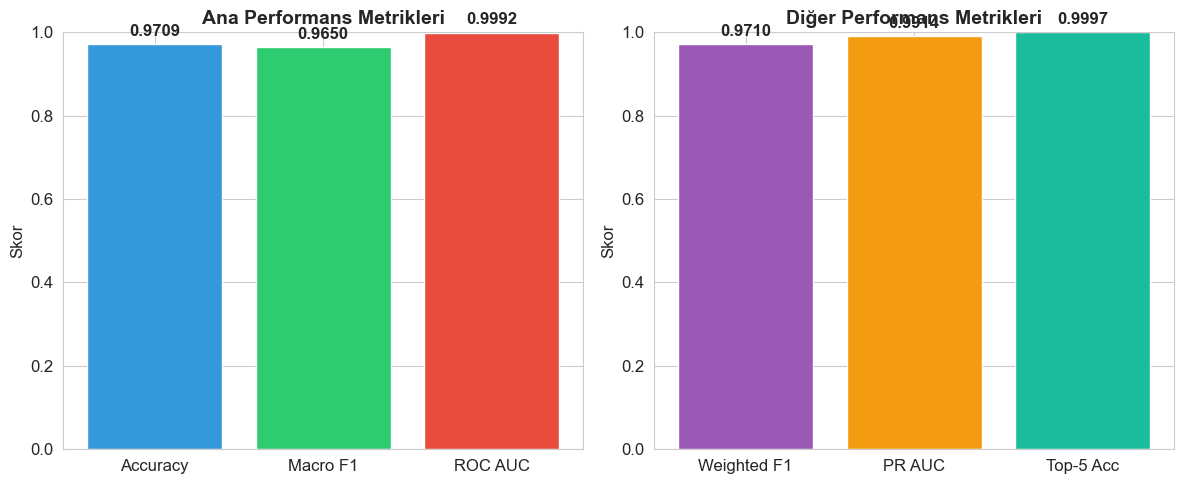

In [19]:
# Metrikleri görselleştir
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Ana metrikler
metrics_main = ['Accuracy', 'Macro F1', 'ROC AUC']
values_main = [test_accuracy, macro_f1, roc_auc]

bars1 = axes[0].bar(metrics_main, values_main, color=['#3498db', '#2ecc71', '#e74c3c'])
axes[0].set_ylim(0, 1)
axes[0].set_title('Ana Performans Metrikleri', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Skor', fontsize=12)

for bar in bars1:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, height + 0.02,
                f'{height:.4f}', ha='center', fontweight='bold')

# 2. Diğer metrikler
metrics_other = ['Weighted F1', 'PR AUC', 'Top-5 Acc']
values_other = [weighted_f1, macro_pr_auc, top5_acc]

bars2 = axes[1].bar(metrics_other, values_other, color=['#9b59b6', '#f39c12', '#1abc9c'])
axes[1].set_ylim(0, 1)
axes[1].set_title('Diğer Performans Metrikleri', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Skor', fontsize=12)

for bar in bars2:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, height + 0.02,
                f'{height:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

Test setini değerlendiriyorum. Modeli evaluation moduna alıp tüm test verisi üzerinde tahminler yapıyorum. Accuracy, F1 (macro ve weighted), Cohen's Kappa, ROC AUC, PR AUC, Top-1 ve Top-5 accuracy gibi kapsamlı metrikleri hesaplıyorum. Sonuçları özet tabloda ve görsel grafiklerde sunuyorum.


Confusion Matrix


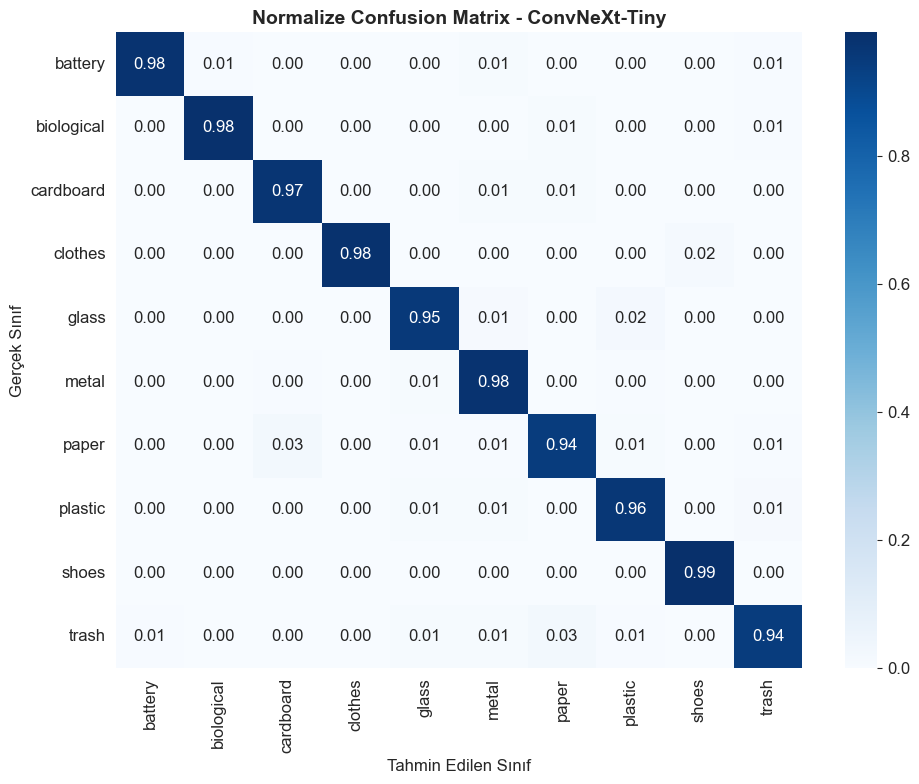

In [20]:
# GÖRSELLEŞTİRMELER
# 1. CONFUSION MATRIX
print("\nConfusion Matrix")
cm = confusion_matrix(all_labels, all_preds, normalize="true")

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Tahmin Edilen Sınıf", fontsize=12)
plt.ylabel("Gerçek Sınıf", fontsize=12)
plt.title("Normalize Confusion Matrix - ConvNeXt-Tiny", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



Model performansını görselleştiriyorum. Normalize confusion matrix ile tahminlerin doğruluk dağılımını gösteriyorum.

Sınıf Bazlı F1 Skorları


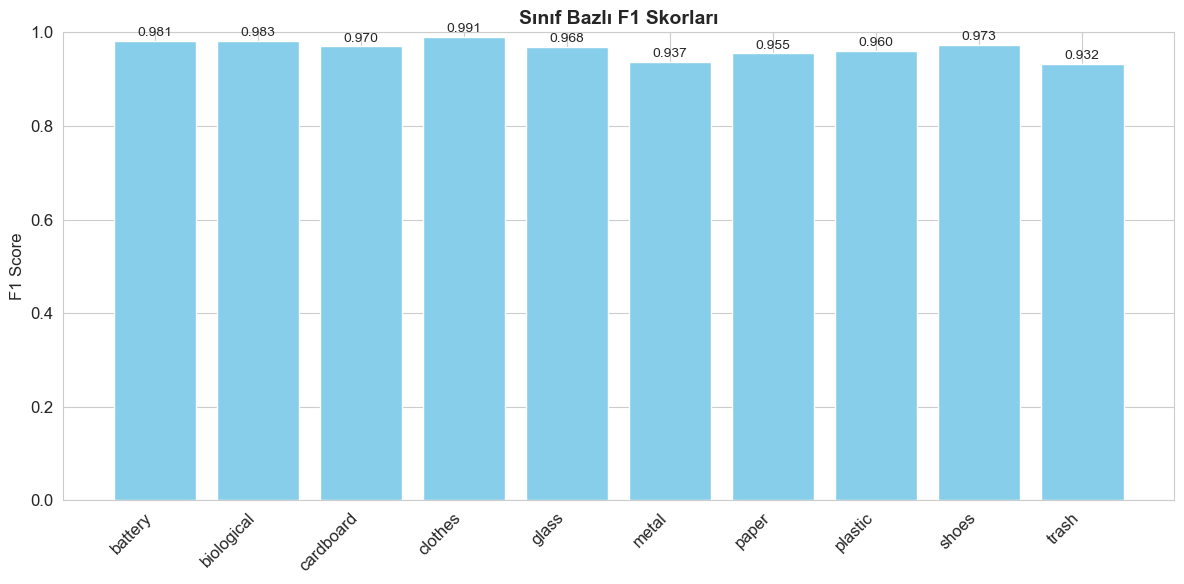

In [21]:
# 2. SINIF BAZLI F1 SCORES
print("Sınıf Bazlı F1 Skorları")
f1_per_class = f1_score(all_labels, all_preds, average=None)

plt.figure(figsize=(12, 6))
bars = plt.bar(range(num_classes), f1_per_class, color='skyblue')
plt.xticks(range(num_classes), class_names, rotation=45, ha='right')
plt.ylabel("F1 Score", fontsize=12)
plt.title("Sınıf Bazlı F1 Skorları", fontsize=14, fontweight='bold')
plt.ylim(0, 1)

for bar, score in zip(bars, f1_per_class):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.01,
            f'{score:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()



Sınıf bazlı F1 skorlarıyla hangi sınıflarda iyi/kötü performans gösterdiğimi analiz ediyorum.


ROC Eğrileri (One-vs-Rest)


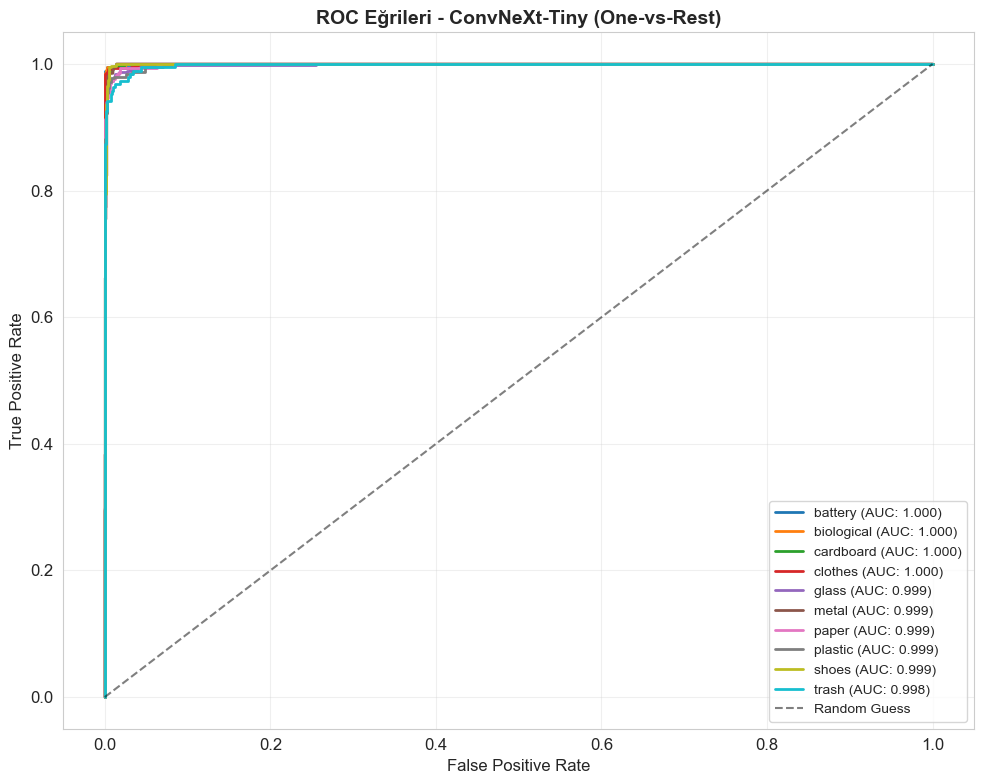

In [22]:
# 3. ROC EĞRİLERİ
print("\nROC Eğrileri (One-vs-Rest)")
plt.figure(figsize=(10, 8))

for i in range(num_classes):
    fpr, tpr, _ = roc_curve((all_labels == i).astype(int), all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC: {roc_auc:.3f})", linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Guess')
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Eğrileri - ConvNeXt-Tiny (One-vs-Rest)", fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Precision-Recall Eğrileri


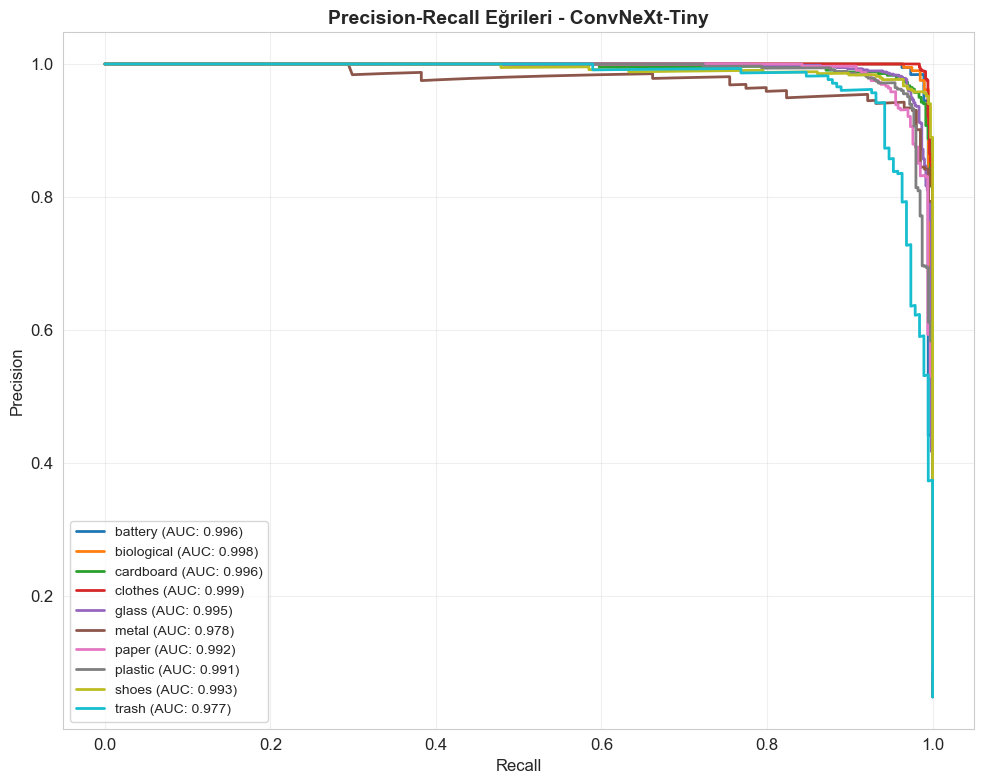

In [23]:
# 4. PR EĞRİLERİ
print("Precision-Recall Eğrileri")
plt.figure(figsize=(10, 8))

for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(
        (all_labels == i).astype(int), all_probs[:, i]
    )
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f"{class_names[i]} (AUC: {pr_auc:.3f})", linewidth=2)

plt.xlabel("Recall", fontsize=12)
plt.ylabel("Precision", fontsize=12)
plt.title("Precision-Recall Eğrileri - ConvNeXt-Tiny", fontsize=14, fontweight='bold')
plt.legend(loc="lower left", fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


ROC eğrileriyle modelin sınıfları ayırma yeteneğini, PR eğrileriyle de imbalanced verideki performansını değerlendiriyorum.

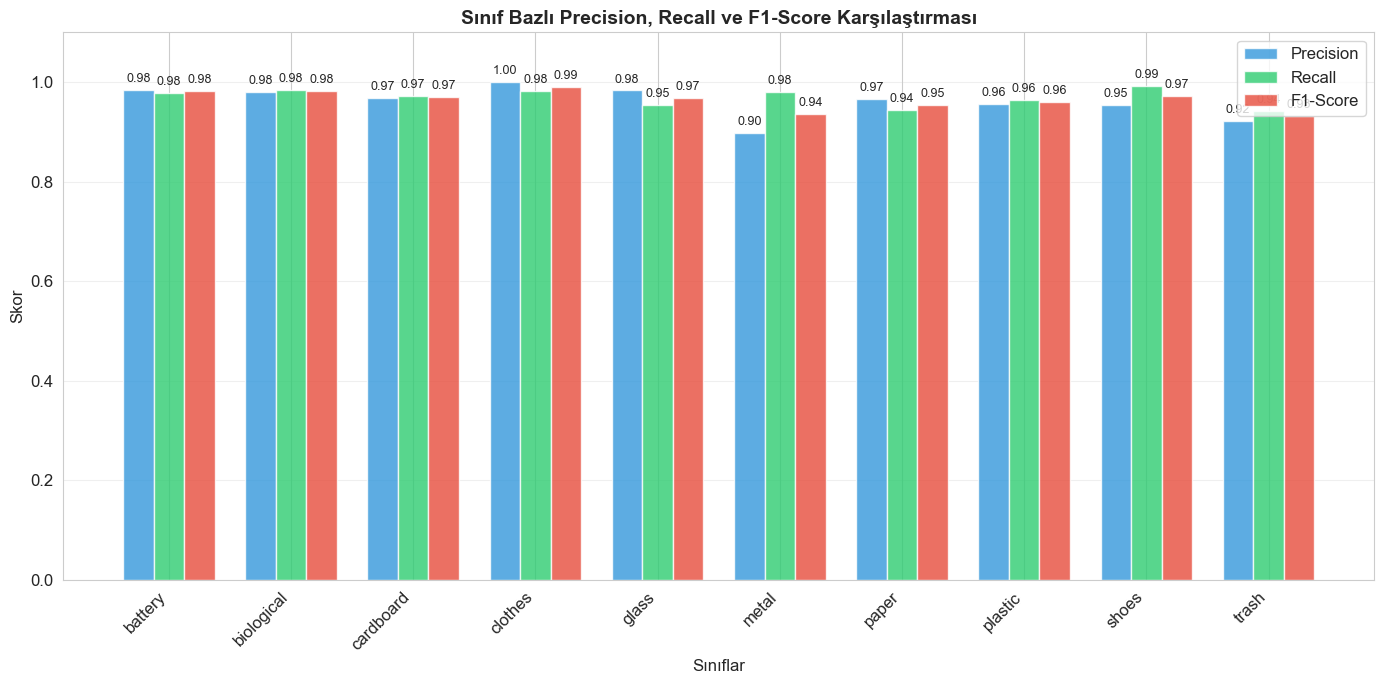

In [24]:
# PRECISION, RECALL, F1-SCORE KARŞILAŞTIRMASI

from sklearn.metrics import precision_score, recall_score

precisions = []
recalls = []
f1_scores = []

for class_idx in range(num_classes):
    y_true_class = (all_labels == class_idx).astype(int)
    y_pred_class = (all_preds == class_idx).astype(int)
    
    precisions.append(precision_score(y_true_class, y_pred_class, zero_division=0))
    recalls.append(recall_score(y_true_class, y_pred_class, zero_division=0))
    f1_scores.append(f1_score(y_true_class, y_pred_class, zero_division=0))

x = np.arange(num_classes)
width = 0.25

fig, ax = plt.subplots(figsize=(14, 7))

bars1 = ax.bar(x - width, precisions, width, label='Precision', color='#3498db', alpha=0.8)
bars2 = ax.bar(x, recalls, width, label='Recall', color='#2ecc71', alpha=0.8)
bars3 = ax.bar(x + width, f1_scores, width, label='F1-Score', color='#e74c3c', alpha=0.8)

ax.set_xlabel('Sınıflar', fontsize=12)
ax.set_ylabel('Skor', fontsize=12)
ax.set_title('Sınıf Bazlı Precision, Recall ve F1-Score Karşılaştırması', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.legend(loc='upper right')
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.3, axis='y')

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2, height + 0.01,
                   f'{height:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


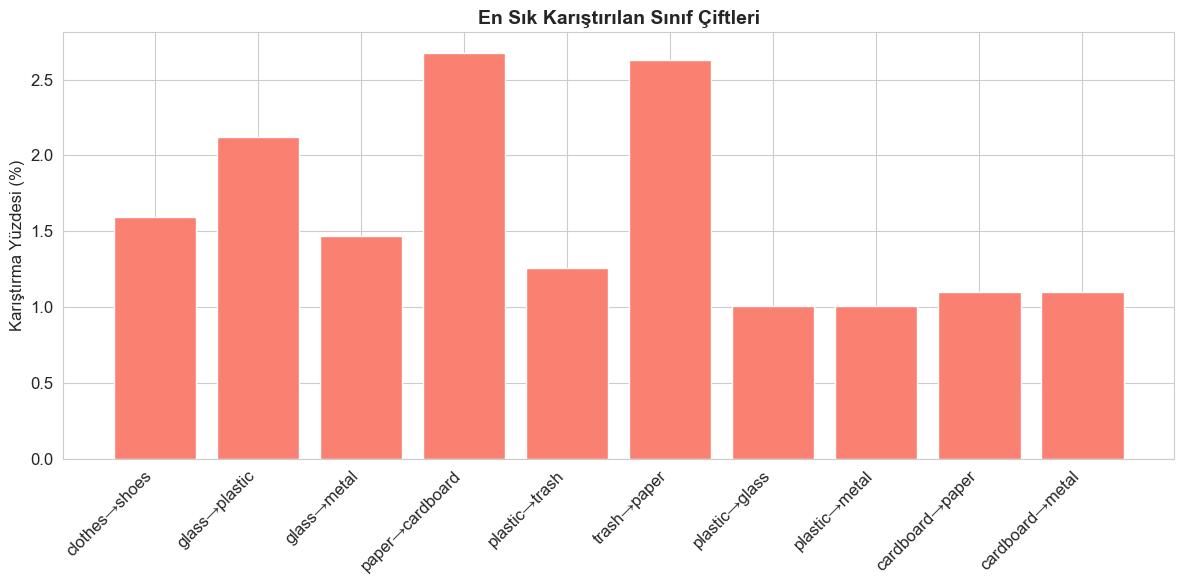

In [25]:
# Confusion matrix'ten en sık karıştırılan sınıfları bul
cm_raw = confusion_matrix(all_labels, all_preds, normalize=None)

# En sık karıştırılan çiftleri bul (kendisi hariç)
misclass_pairs = []
for i in range(num_classes):
    for j in range(num_classes):
        if i != j and cm_raw[i, j] > 0:
            misclass_pairs.append({
                'true_class': class_names[i],
                'pred_class': class_names[j],
                'count': cm_raw[i, j],
                'percent': cm_raw[i, j] / cm_raw[i].sum() * 100
            })

# DataFrame'e çevir ve sırala
misclass_df = pd.DataFrame(misclass_pairs)
if not misclass_df.empty:
    misclass_df = misclass_df.sort_values('count', ascending=False).head(10)

    
    # Görselleştirme
    plt.figure(figsize=(12, 6))
    bars = plt.bar(range(len(misclass_df)), misclass_df['percent'], 
                   color='salmon')
    plt.xticks(range(len(misclass_df)), 
               [f"{row['true_class']}→{row['pred_class']}" 
                for _, row in misclass_df.iterrows()], 
               rotation=45, ha='right')
    plt.ylabel("Karıştırma Yüzdesi (%)", fontsize=12)
    plt.title("En Sık Karıştırılan Sınıf Çiftleri", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("✅ Hiç karıştırma yok!")

In [30]:
# SINIF BAZLI DETAYLI PERFORMANS GÖRSELLEŞTİRMESİ

print("\nPerformans Tablosu:")

styled_df = summary_df_raw.style\
    .format({
        'Accuracy': '{:.2f}%',
        'Precision': '{:.2f}%', 
        'Recall': '{:.2f}%',
        'F1-Score': '{:.2f}%'
    })\
    .background_gradient(subset=['Accuracy', 'Precision', 'Recall', 'F1-Score'], 
                        cmap='YlGn', vmin=90, vmax=100)\
    .set_properties(**{'text-align': 'center'})\
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#2E86C1'), 
                                    ('color', 'white'),
                                    ('font-weight', 'bold'),
                                    ('text-align', 'center')]},
        {'selector': 'td', 'props': [('text-align', 'center')]},
        {'selector': 'tr:hover', 'props': [('background-color', '#D6EAF8')]}
    ])

try:
    display(styled_df)
except Exception as e:
    print(f"⚠️  Tablo gösterilemedi: {e}")
    print("\nAlternatif basit tablo:")
    print(summary_df_display.to_string(index=False))




Performans Tablosu:


,Sınıf,Toplam,Doğru,Accuracy,Precision,Recall,F1-Score,En Çok Karıştığı
0,battery,189,185,99.82%,98.40%,97.88%,98.14%,metal (1.1%)
1,biological,200,197,99.82%,98.01%,98.50%,98.25%,paper (1.0%)
2,cardboard,365,355,99.44%,96.73%,97.26%,96.99%,metal (1.1%)
3,clothes,1065,1046,99.52%,100.00%,98.22%,99.10%,shoes (1.6%)
4,glass,612,584,99.04%,98.32%,95.42%,96.85%,plastic (2.1%)
5,metal,204,200,99.32%,89.69%,98.04%,93.68%,glass (1.0%)
6,paper,336,317,99.24%,96.65%,94.35%,95.48%,cardboard (2.7%)
7,plastic,397,383,99.19%,95.51%,96.47%,95.99%,trash (1.3%)
8,shoes,395,392,99.44%,95.38%,99.24%,97.27%,battery (0.3%)
9,trash,190,179,99.34%,92.27%,94.21%,93.23%,paper (2.6%)


En sonunda tüm sınıflar için değerleri tabloda detaylı şekilde sunuyorum.

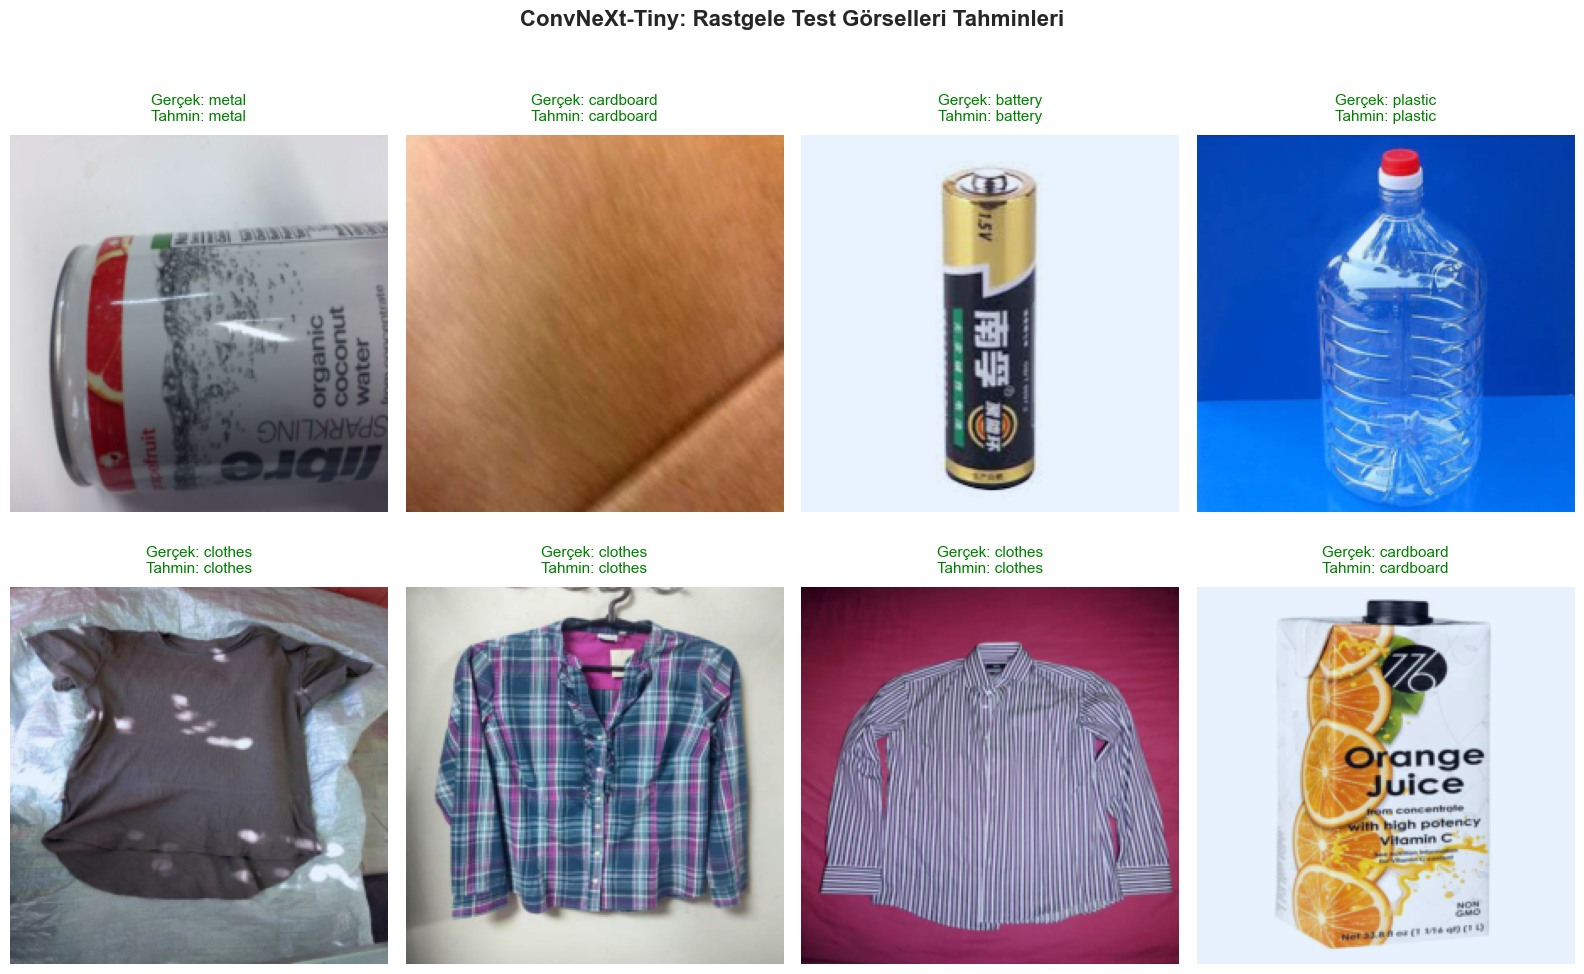

In [31]:
#TAHMİN GÖRSELLEŞTİRMELERİ

def predict_single_image(model, image, device):
    """Tek görüntü tahmini"""
    model.eval()
    with torch.no_grad():
        image = image.unsqueeze(0).to(device)
        outputs = model(image)
        _, pred_class = torch.max(outputs, dim=1)
    return pred_class.item()

def visualize_random_predictions(model, dataset, class_names, device, num_images=8):
    """Rastgele tahmin görselleştirme (confidence olmadan)"""
    import random
    
    indices = random.sample(range(len(dataset)), num_images)
    
    plt.figure(figsize=(16, 10))
    
    for i, idx in enumerate(indices):
        sample = dataset[idx]
        image = sample["image"]
        true_label = sample["label"]
        true_class = class_names[true_label]
        
        pred_label = predict_single_image(model, image, device)
        pred_class = class_names[pred_label]
        
        # Görüntüyü hazırla (normalize geri al)
        img = image.permute(1, 2, 0).cpu().numpy()
        img = (img - img.min()) / (img.max() - img.min())
        
        plt.subplot(2, 4, i + 1)
        plt.imshow(img)
        plt.axis("off")
        
        # Renk: doğru tahmin yeşil, yanlış kırmızı
        color = "green" if pred_label == true_label else "red"
        
        plt.title(f"Gerçek: {true_class}\nTahmin: {pred_class}",
                 color=color, fontsize=11, pad=10)
    
    plt.suptitle("ConvNeXt-Tiny: Rastgele Test Görselleri Tahminleri", 
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

# Fonksiyonu çalıştır
visualize_random_predictions(
    model=model,
    dataset=test_dataset,
    class_names=class_names,
    device=device,
    num_images=8
)

Model tahminlerini görselleştiriyorum. Rastgele 8 test görüntüsü seçip modelin tahminlerini gösteriyorum. Her görüntüde gerçek sınıf, tahmin edilen sınıf ve güven skoru yazıyor. Doğru tahminler yeşil, yanlışlar kırmızı renkle vurgulanıyor. Bu sayede modelin performansını somut örneklerle değerlendiriyorum.